# Logistic Regression — Sentiment Classification

This notebook trains and evaluates a Logistic Regression model using the preprocessed TF-IDF train/test data created in the NLP preprocessing stage.


## 1. Import Libraries

Import the libraries needed to load the processed data, train the model, evaluate its performance, and visualize the confusion matrix.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.sparse import load_npz



## 2. Load the Preprocessed Data

Load the same TF-IDF train/test features and target labels created during preprocessing so the model comparison remains consistent.


In [3]:
# Load TF-IDF train and test features
X_train = load_npz('X_train_tfidf.npz')
X_test = load_npz('X_test_tfidf.npz')

# Load target labels
y_train = pd.read_csv('y_train.csv').squeeze('columns')
y_test = pd.read_csv('y_test.csv').squeeze('columns')


## 3. Train the Logistic Regression Model

Train Logistic Regression using the preprocessed training features and labels.


In [6]:
# Create and train the model
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

## 4. Model Evaluation

Evaluate the trained model on the test data using accuracy, the classification report, and the confusion matrix.


### 4.1 Accuracy


In [12]:
# Predict sentiment for the test data
predictions = model.predict(X_test)

# Calculate model accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {100 * accuracy:.3f}%")


Accuracy: 92.482%


### 4.2 Classification Report


In [18]:
# Display precision, recall, and F1-score for each class
print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.85      0.48      0.61       490
           1       0.93      0.99      0.96      3474

    accuracy                           0.92      3964
   macro avg       0.89      0.73      0.79      3964
weighted avg       0.92      0.92      0.92      3964



### 4.3 Confusion Matrix


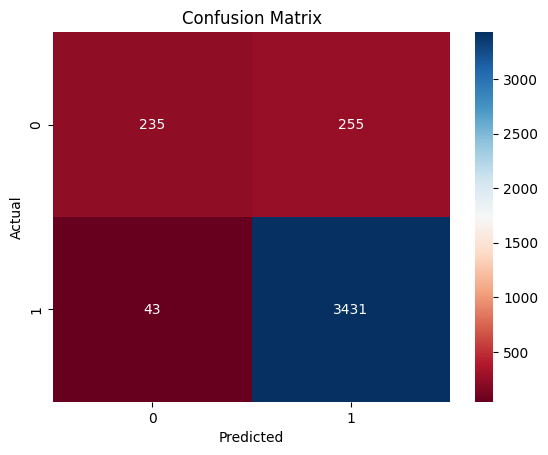

In [22]:
# Calculate and visualize the confusion matrix
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
